In [3]:
%load_ext autoreload
%autoreload 2
## every time we run a cell, check if any 
## currently active modules have been updated

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Integration successful over 20000 time steps.
Initial M1: 0.4000 | Final M1: 0.6414
ODE equilibrium E[x]: 0.6481
Wright's stationary E[x]: 0.7280


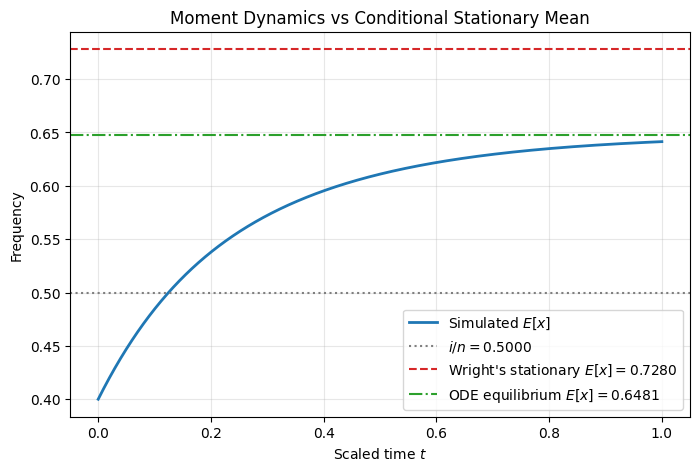

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import hyp1f1
import momentsCoal as mc

a = 4
b = 6
# 1. Define interval parameters
interval_params = {
    'n': 4,
    'i': 2,
    'gamma': 5.0,
    'Ne': 10000,
    't_span': (0.0, 1.0),
    'y0': [0, a / (a + b), (a * b) / ((a + b) * (a + b + 1))]
}

# 2. Execute the functionalized integrator
result = mc.integrate_interval(**interval_params)

# 3. Query the resulting object and plot
if result.success:
    print(f"Integration successful over {len(result.t)} time steps.")
    
    times = result.t
    logZ_trace = result.y[0]
    m1_trace = result.y[1]
    
    print(f"Initial M1: {m1_trace[0]:.4f} | Final M1: {m1_trace[-1]:.4f}")

    # Compute equilibria
    n, i, gamma = interval_params['n'], interval_params['i'], interval_params['gamma']
    m1_ode_eq, _ = mc.compute_ode_equilibrium(n, i, gamma)
    print(f"ODE equilibrium E[x]: {m1_ode_eq:.4f}")

    # Wright's stationary mean: E[x] = (i/n) * 1F1(2i+1; 2n+1; 2γ) / 1F1(2i; 2n; 2γ)
    wright_eq = (i / n) * hyp1f1(2*i + 1, 2*n + 1, 2*gamma) / hyp1f1(2*i, 2*n, 2*gamma)
    print(f"Wright's stationary E[x]: {wright_eq:.4f}")

    # Notebooks handle plotting beautifully inline
    plt.figure(figsize=(8, 5), dpi=100)
    plt.plot(times, m1_trace, label=r'Simulated $E[x]$', color='tab:blue', linewidth=2)
    plt.axhline(y=i/n, color='tab:gray', linestyle=':', label=rf'$i/n = {i/n:.4f}$')
    plt.axhline(y=wright_eq, color='tab:red', linestyle='--', label=rf"Wright's stationary $E[x] = {wright_eq:.4f}$")
    plt.axhline(y=m1_ode_eq, color='tab:green', linestyle='-.', label=rf'ODE equilibrium $E[x] = {m1_ode_eq:.4f}$')

    plt.xlabel("Scaled time $t$")
    plt.ylabel("Frequency")
    plt.title("Moment Dynamics vs Conditional Stationary Mean")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()
else:
    print(f"Integration failed: {result.message}")